# Exercise 05: Stationarity (ADF, transformations)

**CBIOMES Workshop · Time Series in R**

In this notebook you will:

1. Apply a stationarity tests **ADF** to canonical and real series.
2. Apply targeted **transformations** (differencing, detrending, seasonal differencing, segment-wise detrending) and re-test.
3. (Optional) See what happens when you fit an AR model to a series with a deterministic trend without first removing it.

## Setup

All packages already installed in the Docker container.

Expected files: `time_series_example_data.csv`, `NPZ_Narragansett_Example.csv`, `time_series_balticsea.csv`.

In [1]:
#library(tidyverse)
library(tseries)        # adf.test, kpss.test
library(strucchange)    # breakpoints

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: sandwich



## Background the ADF null hypotheses

| Test | $H_0$ | $H_1$ | Reject when |
|---|---|---|---|
| **ADF** (Augmented Dickey–Fuller) | unit root (non-stationary) | stationary | small $p$-value |

With ADF, small $p$ is good (stationary).

---

## Exercise 1: Tests on the five typical series

Run the following code to test the 5 time series if they are stationary or not. 
Start by running the adf test on `df_example$df_example$AR.1....stationary`. Interpret the results.
Then run the code below to get the results for all the time series. Interpret the results

### Hints

- `adf.test(x)$p.value` and extract the $p$-values.
- Wrap calls in `tryCatch(...)` because constant series make the tests crash.

In [3]:
df_example <- read.csv("time_series_example_data.csv", check.names = FALSE)
tseries::adf.test(df_example$AR.1....stationary)


	Augmented Dickey-Fuller Test

data:  df_example$AR.1....stationary
Dickey-Fuller = -3.8414, Lag order = 6, p-value = 0.01733
alternative hypothesis: stationary


In [4]:
# 2. Perform ADF tests on all columns (except the first one)
# names(df_example)[-1] skips the first column (e.g., a Date or ID column)
results <- lapply(names(df_example)[-1], function(nm) {
  
  # Extract the series and remove potential NAs to avoid errors
  s <- na.omit(df_example[[nm]])
  
  # Run the Augmented Dickey-Fuller Test (requires library(tseries))
  # Using a tryCatch is good practice in case a series is constant
  adf <- tryCatch({
    tseries::adf.test(s)
  }, error = function(e) return(NULL))
  
  if (is.null(adf)) {
    return(data.frame(
      Series      = nm,
      ADF_stat    = NA,
      ADF_p       = NA,
      ADF_verdict = "Error",
      stringsAsFactors = FALSE
    ))
  }
  
  data.frame(
    Series      = nm,
    ADF_stat    = round(adf$statistic, 3),
    ADF_p       = round(adf$p.value, 3),
    ADF_verdict = ifelse(adf$p.value < 0.05, "Stationary", "Unit root"),
    stringsAsFactors = FALSE
  )
})

# 3. Combine results into a single dataframe
results_df <- do.call(rbind, results)
results_df

Warning message in tseries::adf.test(s):
“p-value smaller than printed p-value”


,Series,ADF_stat,ADF_p,ADF_verdict
,<chr>,<dbl>,<dbl>,<chr>
Dickey-Fuller,Random.Walk,-1.158,0.912,Unit root
Dickey-Fuller1,AR.1....stationary,-3.841,0.017,Stationary
Dickey-Fuller2,Deterministic.Trend,-8.634,0.010,Stationary
Dickey-Fuller3,Seasonal,-2.700,0.281,Unit root
Dickey-Fuller4,Structural.Break,-0.343,0.989,Unit root


### Reading the table

- AR(1) and Trend → tests say stationary.
- Random walk, structural break, seasonal → non-stationary.

---

## Exercise 1b: Tests on real ecological data

In [5]:
npz         <- as.data.frame(read.csv("NPZ_Narragansett_Example.csv"))
time_series <- as.data.frame(read.csv("time_series_balticsea.csv"))

series_list <- list(
    "P (phytoplankton)" = npz$P,
    "Z (zooplankton)"   = npz$Z,
    "NO3 (nutrient)"    = npz$NO3,
    "Baltic X1"         = time_series[[1]],
    "Baltic X6"         = time_series[[6]]
)

results <- lapply(names(series_list), function(nm) {
  s <- series_list[[nm]]
  adf  <- adf.test(s)
  data.frame(
    Series       = nm,
    ADF_stat     = round(adf$statistic, 3),
    ADF_p        = round(adf$p.value, 3),
    ADF_verdict  = ifelse(adf$p.value < 0.05, "Stationary", "Unit root"),
    stringsAsFactors = FALSE
  )
})
results_df <- do.call(rbind, results)
print(results_df[, c("Series", "ADF_p", "ADF_verdict")])

par(mfrow = c(1, 1))

Warning message in adf.test(s):
“p-value smaller than printed p-value”
Warning message in adf.test(s):
“p-value smaller than printed p-value”
Warning message in adf.test(s):
“p-value greater than printed p-value”


                          Series ADF_p ADF_verdict
Dickey-Fuller  P (phytoplankton) 0.010  Stationary
Dickey-Fuller1   Z (zooplankton) 0.010  Stationary
Dickey-Fuller2    NO3 (nutrient) 0.990   Unit root
Dickey-Fuller3         Baltic X1 0.114   Unit root
Dickey-Fuller4         Baltic X6 0.331   Unit root


For these real ecological series, both tests typically agree on **stationary** — convenient, because we can model them in levels without differencing.

---

## Exercise 2: Transformations to induce stationarity

Each kind of non-stationarity needs its own treatment:

| Type | Transformation |
|---|---|
| Unit root (random walk) | first difference: `diff(x)` |
| Stationary AR(1) | none |
| Deterministic trend | regress on time, keep the residuals |
| Seasonal | seasonal difference: `diff(x, lag = period)` |
| Structural break | locate the break, then segment-wise detrend |

### Hints

- `strucchange::breakpoints()` finds the break location.
- After transformation, run the same tests again the verdicts should flip.

In [6]:
# 1. Random walk → first difference
y_rw_d <- diff(df_example$Random.Walk)

# 2. AR(1) → unchanged
y_ar1_s <- df_example$AR.1....stationary

# 3. Trend → linear detrending
fit_lm   <- lm(df_example$Deterministic.Trend ~ df_example$Time)
y_trend_d <- residuals(fit_lm)

# 4. Seasonal → seasonal differencing (period 52)
y_season_d <- diff(df_example$Seasonal, lag = 52)

# 5. Structural break → estimate break, segment-wise detrending
bp_obj <- breakpoints(df_example$Structural.Break ~ 1, breaks = 1)
bp_idx <- breakpoints(bp_obj)$breakpoints

n_obs <- nrow(df_example)
seg <- rep(1, n_obs)
seg[(bp_idx + 1):n_obs] <- 2
y_break_d <- residuals(lm(df_example$Structural.Break ~ factor(seg)))

cat("Estimated breakpoint at index:", bp_idx, "\n")

# Define segments for the final test list
seg1_data  <- df_example$Structural.Break[1:bp_idx]
seg2_data  <- df_example$Structural.Break[(bp_idx + 1):n_obs]

Estimated breakpoint at index: 148 


In [11]:
# 2. Helper Function: ADF Test
run_tests <- function(s, name) {
  # Handling potential errors in ADF test (e.g., if series is too short)
  adf <- tryCatch(adf.test(s), error = function(e) return(list(p.value = NA)))
  
  data.frame(
    Series       = name,
    ADF_p        = if(is.na(adf$p.value)) NA else round(adf$p.value, 3),
    ADF_verdict  = if(is.na(adf$p.value)) "Error" else ifelse(adf$p.value < 0.05, "Stationary", "Unit root"),
    stringsAsFactors = FALSE
  )
}

# 3. Evaluation

# BEFORE transformation
orig_list <- list(
  "Random Walk"         = df_example$Random.Walk,
  "AR(1) stationary"    = df_example$AR.1....stationary,
  "Deterministic Trend" = df_example$Deterministic.Trend,
  "Seasonal"            = df_example$Seasonal,
  "Structural Break"    = df_example$Structural.Break
)

cat("=== BEFORE transformation ===\n")
print(do.call(rbind, Map(run_tests, orig_list, names(orig_list))))

# --- AFTER transformation (including Segmented Tests) ---
# We align length for plotting, but the test list can handle different lengths
n_min <- min(length(y_rw_d), length(y_trend_d), 
             length(y_season_d), length(y_break_d))

trans_list <- list(
  "RW → diff(1)"          = y_rw_d[1:n_min],
  "AR(1) unchanged"       = y_ar1_s,
  "Trend → detrended"     = y_trend_d[1:n_min],
  "Season → diff(lag=52)" = y_season_d[1:n_min],
  "Break → seg.detrend"   = y_break_d[1:n_min],
  "Break → Segment 1"     = seg1_data,
  "Break → Segment 2"     = seg2_data
)

cat("\n=== AFTER transformation (incl. Segments) ===\n")
print(do.call(rbind, Map(run_tests, trans_list, names(trans_list))))


=== BEFORE transformation ===


Warning message in adf.test(s):
“p-value smaller than printed p-value”


                                 Series ADF_p ADF_verdict
Random Walk                 Random Walk 0.912   Unit root
AR(1) stationary       AR(1) stationary 0.017  Stationary
Deterministic Trend Deterministic Trend 0.010  Stationary
Seasonal                       Seasonal 0.281   Unit root
Structural Break       Structural Break 0.989   Unit root

=== AFTER transformation (incl. Segments) ===


Warning message in adf.test(s):
“p-value smaller than printed p-value”
Warning message in adf.test(s):
“p-value smaller than printed p-value”
Warning message in adf.test(s):
“p-value smaller than printed p-value”
Warning message in adf.test(s):
“p-value smaller than printed p-value”


                                     Series ADF_p ADF_verdict
RW → diff(1)                   RW → diff(1) 0.010  Stationary
AR(1) unchanged             AR(1) unchanged 0.017  Stationary
Trend → detrended         Trend → detrended 0.010  Stationary
Season → diff(lag=52) Season → diff(lag=52) 0.010  Stationary
Break → seg.detrend     Break → seg.detrend 0.533   Unit root
Break → Segment 1         Break → Segment 1 0.010  Stationary
Break → Segment 2         Break → Segment 2 0.958   Unit root


### Visual comparison: original vs. transformed

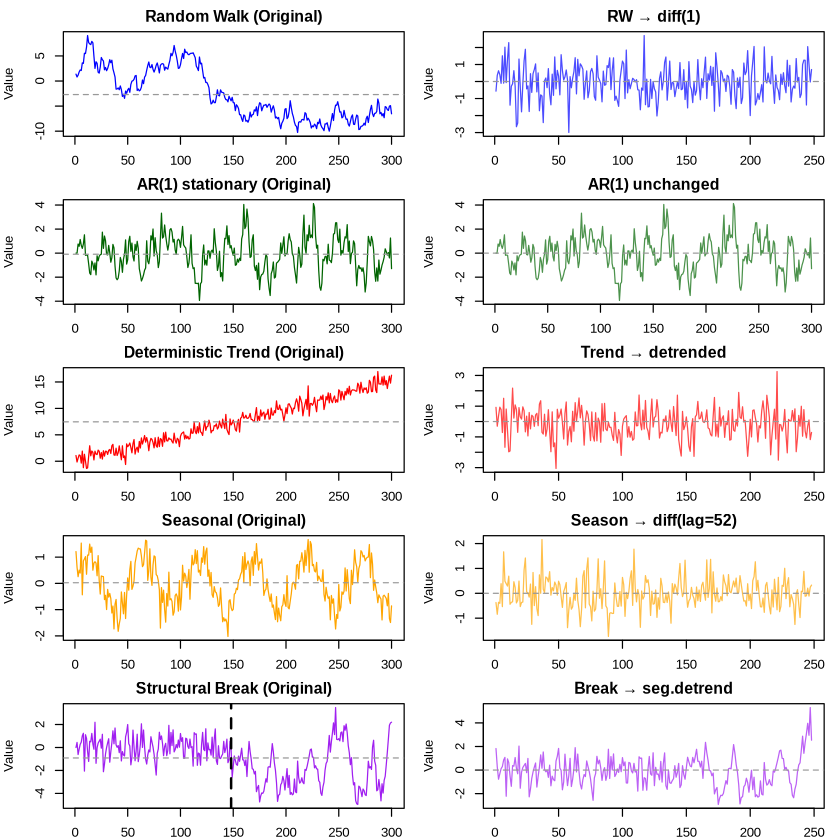

In [12]:
# 4. Visual Comparison
par(mfrow = c(5, 2), mar = c(2, 4, 2, 1))
cols <- c("blue", "darkgreen", "red", "orange", "purple")

# We iterate through the first 5 (original pairs)
for (k in 1:5) {
  s_orig  <- orig_list[[k]]
  s_trans <- trans_list[[k]]
  
  # Original Series Plot
  plot(s_orig, type = "l", col = cols[k],
       main = paste(names(orig_list)[k], "(Original)"),
       ylab = "Value", xlab = "")
  abline(h = mean(s_orig), lty = 2, col = "grey60")
  
  if (names(orig_list)[k] == "Structural Break") {
    abline(v = bp_idx, lty = 2, lwd = 2, col = "black")
  }
  
  # Transformed Series Plot
  plot(s_trans, type = "l", col = adjustcolor(cols[k], 0.7),
       main = paste(names(trans_list)[k]),
       ylab = "Value", xlab = "")
  abline(h = 0, lty = 2, col = "grey60")
}

# Reset plotting parameters
par(mfrow = c(1, 1))

---

## (Optional) Exercise 3: Fitting AR on a trended series (a cautionary tale)

What if we ignore the trend and just fit an AR? Spoiler: the model picks an inflated lag order and the autoregressive coefficients are misleading.

In [9]:
set.seed(123)
T <- 300
z_trend <- numeric(T)
for (t in 2:T) {
    z_trend[t] <- 0.1 * t + 0.8 * z_trend[t - 1] + rnorm(1)
}

# (a) AR directly on the trended series
fit_raw <- ar(z_trend, method = "ols", order.max = 5)
cat("AR on raw trended series:\n")
cat(sprintf("  AIC-selected order : %d\n", fit_raw$order))
cat(sprintf("  Estimated phi      : %s\n",
            paste(round(fit_raw$ar, 4), collapse = ", ")))

# (b) Detrend, then AR
fit_lm   <- lm(z_trend ~ I(1:T))
z_resid  <- residuals(fit_lm)
fit_detr <- ar(z_resid, method = "ols", order.max = 5)
cat("\nAR on detrended residuals:\n")
cat(sprintf("  AIC-selected order : %d\n", fit_detr$order))
cat(sprintf("  Estimated phi      : %s\n",
            paste(round(fit_detr$ar, 5), collapse = ", ")))

AR on raw trended series:
  AIC-selected order : 5
  Estimated phi      : 0.8585, -0.0441, 0.1032, -0.1073, 0.1903

AR on detrended residuals:
  AIC-selected order : 1
  Estimated phi      : 0.74798


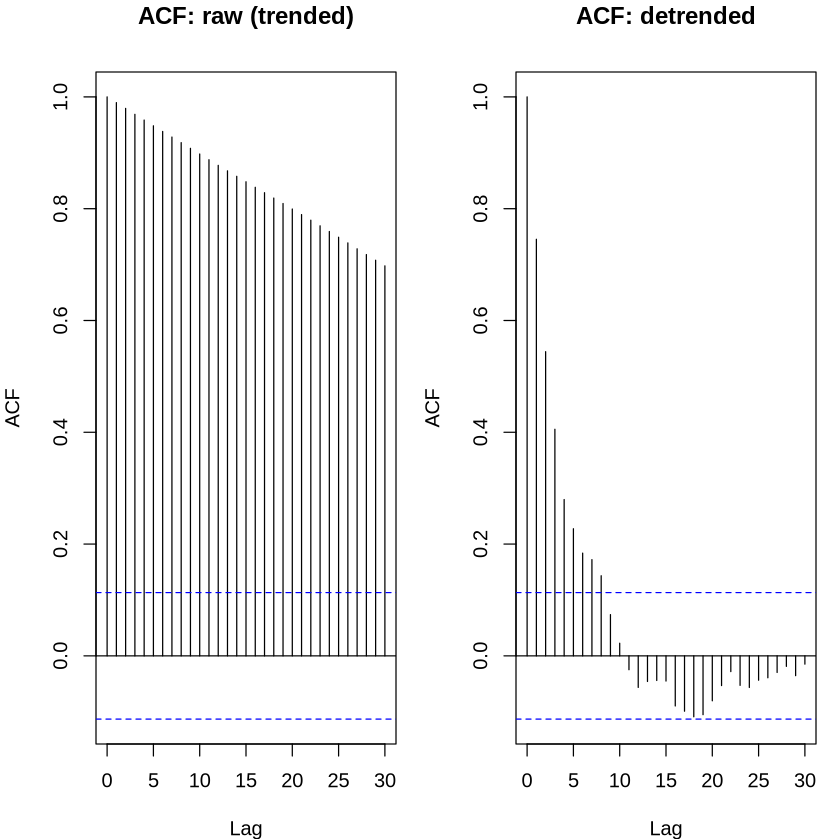

In [10]:
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
acf(z_trend, lag.max = 30, main = "ACF: raw (trended)")
acf(z_resid, lag.max = 30, main = "ACF: detrended")
par(mfrow = c(1, 1))

### What just happened?

The ACF of the raw series shows a slow, near-linear decay. That's the signature of trend, not of long memory. Because the AR model has no concept of "trend", it spends parameters on lag terms trying to mimic the drift, inflating the chosen lag order. After detrending, the ACF decays geometrically and the model correctly settles on an AR(1) close to the true $\phi = 0.8$.

### Discussion

- Which non-stationarity types are hardest to detect visually?
- How does each transformation affect downstream models (AR, VAR, forecasting)?

### Common pitfalls

- Differencing a stationary series, that introduces over-differencing artifacts.
- Detrending an already stationary series is usually harmless but unnecessary.
- Treating a structural break as a unit root and just differencing, you lose the level information.

---

## Wrap-up

- Apply ADF and KPSS, and reconcile their (sometimes contradictory) verdicts.
- Match a transformation to each kind of non-stationarity.
- See concretely why detrending matters before fitting an AR.

Next: from one variable to **multivariate VAR** models (Exercise 06).